In [20]:
import pandas as pd

with zipfile.ZipFile(
    r"C:\Users\Arvind\Downloads\Sample data for project\E-Commerce Sales Dataset.zip"
) as z:
    df = pd.read_csv(z.open("Amazon Sale Report.csv"))

print(df.shape)
print(df.columns)
df.head()

(128975, 24)
Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')


C:\Users\Arvind\AppData\Local\Temp\ipykernel_20012\2260842071.py:6: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open("Amazon Sale Report.csv"))


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [23]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
 # Remove useless column
df.drop(columns=['Unnamed: 22'], inplace=True)

# Remove rows where Amount is missing
df = df.dropna(subset=['Amount'])

# Check missing values again
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         5136
Qty                       0
currency                  0
Amount                    0
ship-city                31
ship-state               31
ship-postal-code         31
ship-country             31
promotion-ids         41698
B2B                       0
fulfilled-by          83639
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month_name()

df[['Date', 'Month']].head()

C:\Users\Arvind\AppData\Local\Temp\ipykernel_20012\1180320791.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


,Date,Month
0,2022-04-30,April
1,2022-04-30,April
2,2022-04-30,April
3,2022-04-30,April
4,2022-04-30,April


In [30]:
# Analysis 1: Order Status Distribution

status_counts = df["Status"].value_counts()
print(status_counts.head(10))

Status
Shipped                          77596
Shipped - Delivered to Buyer     28761
Cancelled                        10766
Shipped - Returned to Seller      1950
Shipped - Picked Up                973
Pending                            656
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Name: count, dtype: int64


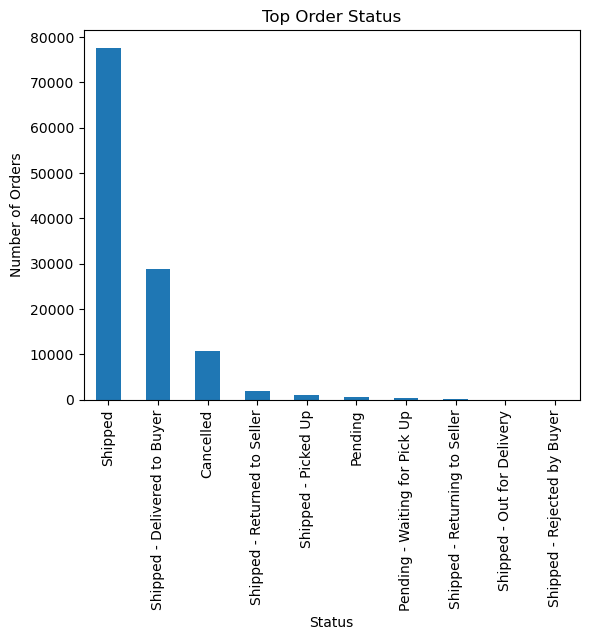

In [31]:
import matplotlib.pyplot as plt

status_counts.head(10).plot(kind='bar')

plt.title('Top Order Status')
plt.ylabel('Number of Orders')
plt.show()

In [32]:
# Analysis 2: Top Categories by Sales

category_sales = (
    df.groupby('Category')['Amount']
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Set              39204124.03
kurta            21299546.70
Western Dress    11216072.69
Top               5347792.30
Ethnic Dress       791217.66
Blouse             458408.18
Bottom             150667.98
Saree              123933.76
Dupatta               915.00
Name: Amount, dtype: float64


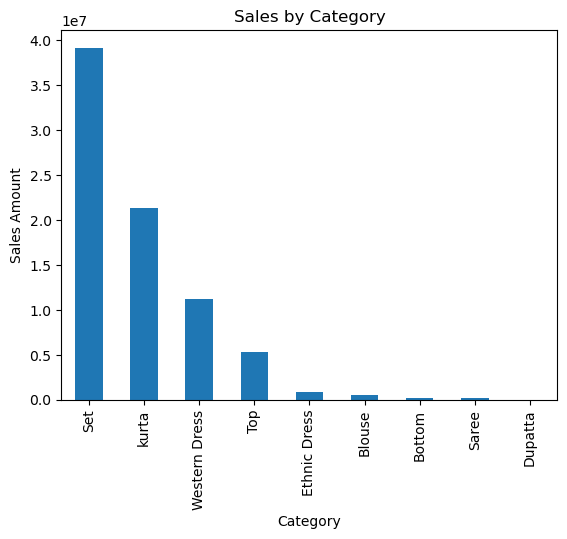

In [33]:
category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.ylabel('Sales Amount')
plt.show()

In [34]:
# Analysis 3: Top 10 States by Sales
top_states = (
    df.groupby('ship-state')['Amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_states)

ship-state
MAHARASHTRA       13335534.14
KARNATAKA         10481114.37
TELANGANA          6916615.65
UTTAR PRADESH      6816642.08
TAMIL NADU         6515650.11
DELHI              4235215.97
KERALA             3830227.58
WEST BENGAL        3507880.44
ANDHRA PRADESH     3219831.72
HARYANA            2882092.99
Name: Amount, dtype: float64


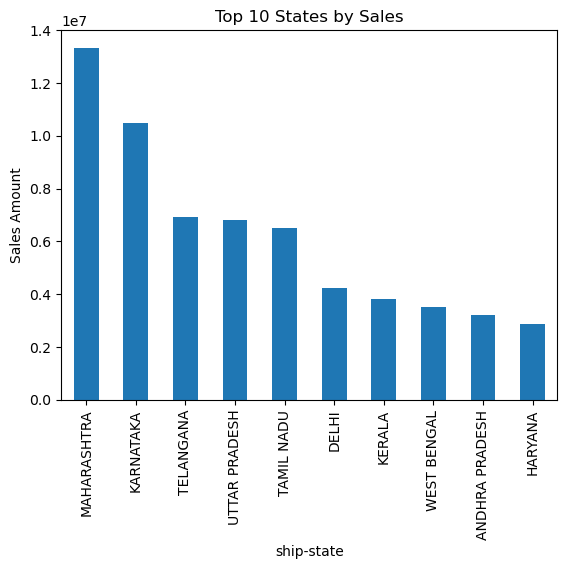

In [35]:
top_states.plot(kind='bar')

plt.title('Top 10 States by Sales')
plt.ylabel('Sales Amount')
plt.show()

In [36]:
# Analysis 4: Monthly Sales Trend

monthly_sales = (
    df.groupby('Month')['Amount']
      .sum()
      .sort_values(ascending=False)
)

print(monthly_sales)

Month
April    28838708.32
May      26226476.75
June     23425809.38
March      101683.85
Name: Amount, dtype: float64


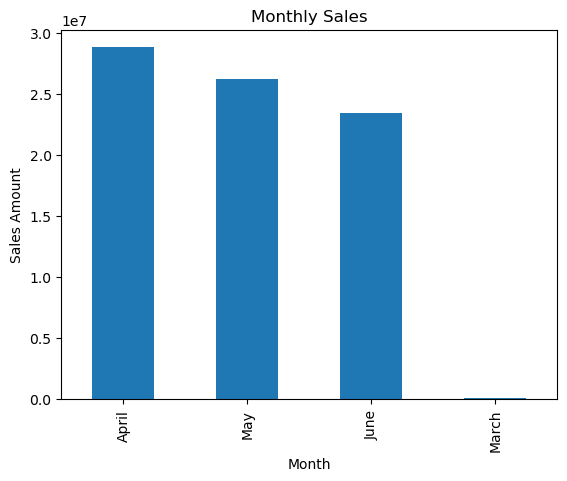

In [37]:
monthly_sales.plot(kind='bar')

plt.title('Monthly Sales')
plt.ylabel('Sales Amount')
plt.show()

# Amazon E-Commerce Sales Analysis

## Project Overview
This project analyzes Amazon e-commerce sales data using Python and Pandas.

The objective is to identify sales trends, top-performing categories, customer order patterns, and state-wise sales performance.

## Dataset
Amazon Sale Report Dataset

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

## Analysis Performed
- Data Cleaning
- Missing Value Handling
- Order Status Analysis
- Category-wise Sales Analysis
- State-wise Sales Analysis
- Monthly Sales Trend Analysis

## Key Findings

### Order Status
- Shipped orders: 77,596
- Delivered orders: 28,761
- Cancelled orders: 10,766

### Top Categories
1. Set
2. Kurta
3. Western Dress

### Top States
1. Maharashtra
2. Karnataka
3. Telangana

### Monthly Trend
- April recorded the highest sales.

## Conclusion
The analysis reveals that the Set category generated the highest revenue, Maharashtra contributed the highest sales, and most orders were successfully shipped and delivered.